In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
import dutta_test.utils as utils
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplAI.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 6050 rows from spikes\all_networks_metrics_ripplAI.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-22_17-42-27,24,0.1,CNN1D_1,96,256,13,0.272727,0.880734,0.416486,10.148958,421,109,10.506607
1,2025-09-22_17-42-27,24,0.1,CNN1D_2,61,17,48,0.782051,0.559633,0.652406,13.282514,82,109,10.506607
2,2025-09-22_17-42-27,24,0.1,CNN1D_3,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109,10.506607
3,2025-09-22_17-42-27,24,0.1,CNN1D_4,73,40,36,0.646018,0.669725,0.657658,9.045662,116,109,10.506607
4,2025-09-22_17-42-27,24,0.1,CNN1D_5,87,207,22,0.295918,0.798165,0.431762,7.213410,324,109,10.506607


In [4]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    "2025-09-24_14-22-55", #H
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        # #  "2025-09-24_11-34-51", # Nothing concrete
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique())
print(len(df["Session"].unique()))
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-24_11-34-51'
 '2025-09-24_16-29-07' '2025-09-25_11-21-53' '2025-09-25_16-41-14'
 'Calbai32FPGA_251003_144832' 'Calbai32FPGA_251003_150055'
 'Calb_251209_160255' 'Calb_251210_115904' 'Calb_251210_122327'
 'Calb_251210_162849' 'Calb_251210_164150' 'Calb_251210_165332'
 'Calb_251211_104316' 'Calb_251211_105518' 'Calb_251211_110650'
 'PV01ai32FPGA_250611_115923' 'PV01ai32FPGA_250611_122326'
 'Calb_251210_121141']
23


In [5]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.4,0.409,0.511,0.523,61.911,127.496,56.306
0.3,0.401,0.442,0.593,70.247,192.497,47.970
0.5,0.399,0.564,0.455,53.976,87.273,64.242
0.6,0.377,0.612,0.392,46.623,59.492,71.595
0.2,0.370,0.352,0.676,80.210,322.169,38.007
0.7,0.349,0.626,0.328,39.063,37.570,79.155
0.8,0.300,0.598,0.255,30.282,20.913,87.936
0.1,0.293,0.234,0.774,93.853,701.904,26.602
0.9,0.238,0.602,0.175,20.847,7.995,97.370


In [6]:

summary = df.groupby(["Model","Threshold"])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary.head())

F1  Precision  Recall      TP       FP      FN
Model  Threshold                                                   
LSTM_5 0.4        0.596      0.643   0.624  74.652   50.739  43.565
       0.5        0.588      0.704   0.565  67.304   34.043  50.913
       0.3        0.583      0.577   0.673  80.261   75.348  37.957
       0.6        0.575      0.761   0.510  60.609   22.304  57.609
       0.2        0.562      0.526   0.729  86.522  113.261  31.696

In [7]:
df['Model'] = df['Model'].str.extract(r'(CNN1D|CNN2D|LSTM|SVM|XGBOOST)', expand=False)
# Print summary by Threshold and Model
print("\n--- Summary by Threshold and Model ---")
summary = df.groupby(['Threshold', 'Model'])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3)
display(summary)


--- Summary by Threshold and Model ---


F1  Precision  Recall     TP      FP     FN
Threshold Model                                                  
0.1       CNN1D    0.429      0.330   0.703   80.5   154.5   30.5
          CNN2D    0.397      0.368   0.590   60.5    85.5   48.5
          LSTM     0.277      0.168   0.925   97.5   407.0    8.0
          SVM      0.165      0.090   0.935  102.5  1061.5    7.0
          XGBOOST  0.157      0.086   0.900   99.0  1108.0   11.0
0.2       CNN1D    0.495      0.481   0.594   67.0    62.0   42.0
          CNN2D    0.416      0.547   0.450   43.0    33.0   62.0
          LSTM     0.445      0.308   0.839   83.0   150.0   17.0
          SVM      0.279      0.171   0.832   86.0   415.0   20.0
          XGBOOST  0.263      0.156   0.882   97.0   498.0   12.0
0.3       CNN1D    0.478      0.580   0.508   54.0    34.0   51.0
          CNN2D    0.408      0.671   0.339   31.0    16.0   70.0
          LSTM     0.487      0.444   0.733   73.0    65.0   30.0
          SVM      0.351      0.240   0.748   76.0   229.0   30.0
          XGBOOST  0.338      0.209   0.839   95.0   300.0   18.0
0.4       CNN1D    0.460      0.670   0.453   48.0    20.0   59.0
          CNN2D    0.369      0.750   0.261   23.0     6.0   73.0
          LSTM     0.529      0.562   0.632   62.0    31.0   39.0
          SVM      0.403      0.310   0.676   61.0   137.0   39.0
          XGBOOST  0.400      0.269   0.789   86.0   192.0   23.0
0.5       CNN1D    0.452      0.754   0.375   38.0    13.0   67.0
          CNN2D    0.263      0.788   0.162   16.0     2.0   84.0
          LSTM     0.537      0.647   0.516   52.0    13.0   48.0
          SVM      0.415      0.374   0.605   53.0    83.0   49.0
          XGBOOST  0.455      0.326   0.746   80.0   141.0   31.0
0.6       CNN1D    0.418      0.800   0.300   32.0     7.0   71.0
          CNN2D    0.159      0.833   0.087    9.0     1.0   90.0
          LSTM     0.489      0.716   0.422   40.0     5.0   62.0
          SVM      0.408      0.454   0.527   46.0    54.0   59.0
          XGBOOST  0.500      0.408   0.688   75.0    98.0   37.0
0.7       CNN1D    0.348      0.833   0.232   26.0     3.0   72.0
          CNN2D    0.093      0.857   0.050    5.0     0.0   91.0
          LSTM     0.413      0.765   0.282   31.0     1.0   72.0
          SVM      0.397      0.488   0.427   37.0    30.0   68.0
          XGBOOST  0.538      0.488   0.606   70.0    54.0   47.0
0.8       CNN1D    0.277      0.857   0.162   18.0     2.0   80.0
          CNN2D    0.074      0.846   0.038    3.0     0.0   92.0
          LSTM     0.055      0.622   0.028    4.0     0.0   91.0
          SVM      0.388      0.551   0.346   31.0    16.0   72.0
          XGBOOST  0.519      0.602   0.523   54.0    26.0   59.0
0.9       CNN1D    0.182      0.873   0.103   11.0     1.0   91.0
          CNN2D    0.030      0.821   0.015    2.0     0.0  100.0
          LSTM     0.000      0.000   0.000    0.0     0.0   97.0
          SVM      0.293      0.646   0.177   24.0     5.0   81.0
          XGBOOST  0.491      0.816   0.356   37.0     6.0   71.0

In [8]:
print(summary.loc[summary["F1"].idxmax()])

F1            0.538
Precision     0.488
Recall        0.606
TP           70.000
FP           54.000
FN           47.000
Name: (0.7, XGBOOST), dtype: float64


In [9]:
# Print summary
print("\n--- Summary by Session ---")
summary = df[(df["Threshold"]==0.5) & (df["Model"]=="XGBOOST")].groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Session ---


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-22_17-55-26,0.651,0.731,0.606,112.2,46.4,72.8
Calb_251210_165332,0.626,0.528,0.807,73.4,73.0,17.6
2025-09-22_17-42-27,0.605,0.577,0.670,73.0,60.2,36.0
Calb_251209_160255,0.603,0.476,0.842,55.6,64.4,10.4
2025-09-25_11-21-53,0.580,0.630,0.564,114.0,72.6,88.0
2025-09-25_16-41-14,0.562,0.499,0.672,96.8,104.0,47.2
2025-09-23_15-50-26,0.553,0.495,0.681,94.6,111.8,44.4
Calb_251210_164150,0.515,0.396,0.778,91.8,154.4,26.2
Calb_251211_105518,0.497,0.363,0.827,108.4,206.4,22.6


In [10]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

C:\Users\NCN\AppData\Local\Temp\ipykernel_38764\1839581969.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=threshold_values)


N=22 matched samples for statistics.
0.1 vs 0.2: p=0.0014 True
0.1 vs 0.3: p=0.0006 True
0.1 vs 0.4: p=0.0017 True
0.1 vs 0.5: p=0.0188 True
0.1 vs 0.6: p=0.0624 False
0.1 vs 0.7: p=0.4616 False
0.1 vs 0.8: p=1.0000 False
0.2 vs 0.3: p=0.0399 True
0.2 vs 0.4: p=0.1488 False
0.2 vs 0.5: p=0.4250 False
0.2 vs 0.6: p=1.0000 False
0.2 vs 0.7: p=1.0000 False
0.2 vs 0.8: p=0.0533 False
0.3 vs 0.4: p=0.4616 False
0.3 vs 0.5: p=1.0000 False
0.3 vs 0.6: p=1.0000 False
0.3 vs 0.7: p=1.0000 False
0.3 vs 0.8: p=0.0114 True
0.4 vs 0.5: p=1.0000 False
0.4 vs 0.6: p=1.0000 False
0.4 vs 0.7: p=0.2965 False
0.4 vs 0.8: p=0.0041 True
0.5 vs 0.6: p=0.3277 False
0.5 vs 0.7: p=0.0771 False
0.5 vs 0.8: p=0.0021 True
0.6 vs 0.7: p=0.0624 False
0.6 vs 0.8: p=0.0017 True
0.7 vs 0.8: p=0.0021 True


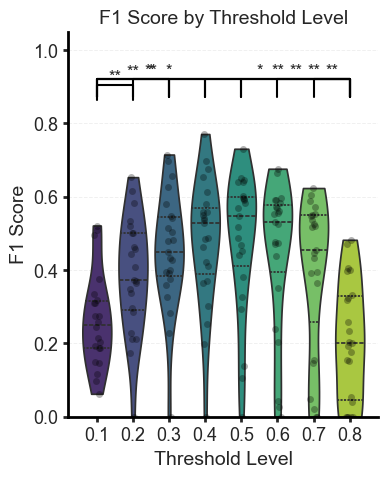

In [27]:
from snnTorch.generalization_madrid.utils import holm_bonferroni

# Define shared color palette for consistency across plots
# Get viridis colors based on number of thresholds (will be determined dynamically)
def get_threshold_colors(adapt_values):
    """Get consistent viridis colors for thresholds."""
    return sns.color_palette("viridis", len(adapt_values))

def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False,aggregate_by_session=False,model="CNN1D",thresholds_to_include=None,figsize=(5,6)):

    threshold_values=thresholds_to_include if thresholds_to_include is not None else sorted(df["Threshold"].unique())

    mask= ((df["Model"]==model) & (df["Threshold"].isin(threshold_values)))
    df = df[mask]

    if aggregate_by_session:
        plot_df = df.groupby(["Session", "Threshold"])[metric].median().reset_index()
    else:
        plot_df = df    



    fig, ax = plt.subplots(figsize=figsize)
    
    # Boxplot
    # sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=threshold_values)
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=threshold_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    p_values=[]
    pairs=[]
    if len(pivot) > 0:
        centers = range(len(threshold_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(threshold_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = threshold_values[i]
            a2 = threshold_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                p_values.append(p)
                pairs.append((a1, a2))

                
                # Stacking logic for brackets
                # h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                # print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
            
        corrected_significant, adjusted_pvals=utils.holm_bonferroni(p_values,alpha=0.05)
        for p,sig,(b1,b2) in zip(adjusted_pvals,corrected_significant,pairs):        
                print(f"{b1} vs {b2}: p={p:.4f} {sig}")          
                barplot_annotate_brackets(threshold_values.index(b1), threshold_values.index(b2), p, centers, [max_val+0.05]*len(centers), ax, fs=12, maxasterix=3)   

    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)   
   
    ax.set_title(f"{metric} Score by Threshold Level",fontsize=14)
    ax.set_ylim(0, 1.05) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')

    plt.show()
    return fig,ax
if 'df' in locals():
   fig,ax = plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_session=True,figsize=(4,5),model="LSTM",thresholds_to_include=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8])

Precision    Recall
Threshold                          
0.1       0.25   0.105104  0.903083
          0.50   0.152864  0.948193
          0.75   0.190104  0.963274
0.2       0.25   0.172938  0.730715
          0.50   0.261380  0.868132

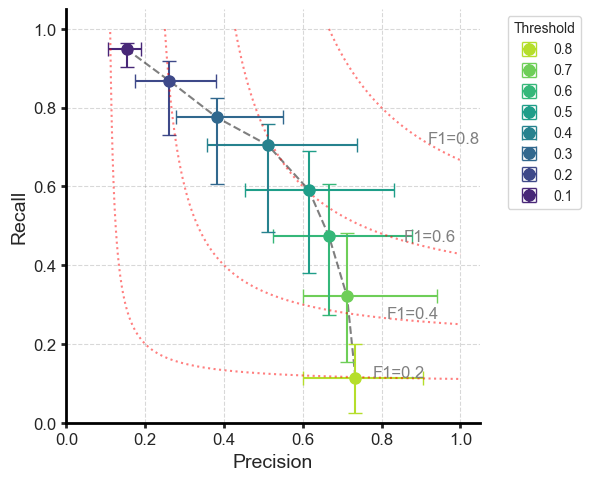

In [30]:
def plot_precision_recall_curve(df, thresholds_to_include=None, aggregate_by_session=True,model="XGBOOST"):
    # Filter for specific buffer size if needed, e.g., buffer=6
    threshold_values=thresholds_to_include if thresholds_to_include is not None else sorted(df["Threshold"].unique())
    mask=(df["Threshold"].isin(threshold_values) & (df["Model"]==model)) 
    df_subset = df[mask].copy()
    if aggregate_by_session:
        df_subset = df_subset.groupby(["Session", "Threshold"])[["Precision", "Recall"]].median().reset_index()

    # Calculate median (50%), 25%, and 75% quantiles
    summary = df_subset.groupby("Threshold")[["Precision", "Recall"]].quantile([0.25, 0.5, 0.75]) # one row per threshold per quantile
    display(summary.head())
    # Sort index appropriately for plotting logic
    # Unstack to get columns like (Precision, 0.5), (Precision, 0.25) ...
    summary = summary.unstack(level=1) # create multi-index columns # Metric, Quantile
    # display(summary.head()  )
    # Extract Medians as the central point
    means = summary.xs(0.5, axis=1, level=1).sort_index(ascending=False) # Extract median values (Threshold, Metric)
    # display(means.head())

    # Calculate IQR errors:
    # lower_err = median - Q1
    # upper_err = Q3 - median
    q1 = summary.xs(0.25, axis=1, level=1).sort_index(ascending=False) # Extract Q1 values (Threshold, Metric)
    q3 = summary.xs(0.75, axis=1, level=1).sort_index(ascending=False) # Extract Q3 values (Threshold, Metric)
    
    # Define errors for errorbar plot (shape: 2xN for each point [lower, upper])
    # Precision Errors
    prec_err_lower = means["Precision"] - q1["Precision"]
    prec_err_upper = q3["Precision"] - means["Precision"]
    
    # Recall Errors
    rec_err_lower = means["Recall"] - q1["Recall"]
    rec_err_upper = q3["Recall"] - means["Recall"]
    
    thresholds = means.index.values

    fig,ax=plt.subplots(figsize=(6,6))
    
    # Plot the line connecting the medians
    ax.plot(means["Precision"], means["Recall"], 'k--', alpha=0.5)
    
    # Plot points with IQR error bars
    sorted_thresholds = sorted(thresholds)
    # Use same viridis colors as cell 8
    colors = get_threshold_colors(sorted_thresholds)
    color_map = {th: col for th, col in zip(sorted_thresholds, colors)}
    
    for i, th in enumerate(thresholds):
        # Prepare error arrays (needs to be sequence of shape (2, 1) or scalar if symmetric, but here asymmetric)
        xerr = [[prec_err_lower[th]], [prec_err_upper[th]]]
        yerr = [[rec_err_lower[th]], [rec_err_upper[th]]]
        
        ax.errorbar(means.loc[th, "Precision"], means.loc[th, "Recall"], 
                     xerr=xerr, 
                     yerr=yerr, 
                     fmt='o', color=color_map[th], 
                     capsize=5, label=f'{th}', markersize=8)

    # Add F1 isolines for reference
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0, 1, 10000)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        valid = (y > 0) & (y < 1)
        ax.plot(x[valid], y[valid], 'r:', linewidth=1.5,alpha=0.5)
        if any(valid):
            ax.text(x[valid][int(len(x[valid])*0.75)], y[valid][int(len(y[valid])*0.75)], f"F1={f1}", color='gray', fontsize=12)

    ax.set_xlabel("Precision",fontsize=14)
    ax.set_ylabel("Recall",fontsize=14)
    ax.set_xlim(0,1.05)
    ax.set_ylim(0,1.05)
    
    # Set Aspect Ratio to be Equal
    ax.set_aspect('equal', adjustable='box')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2,bottom=True, left=True)
    ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.3)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Threshold")
    plt.tight_layout()
    plt.show()  
    return fig,ax
fig,ax = plot_precision_recall_curve(df,model="LSTM",thresholds_to_include=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8])

C:\Users\NCN\AppData\Local\Temp\ipykernel_38764\2637607332.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\NCN\AppData\Local\Temp\ipykernel_38764\2637607332.py:23: UserWarning: 
The palette list has fewer values (4) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)


0.1 vs 0.2: p=0.0000
0.1 vs 0.3: p=0.0000
0.1 vs 0.4: p=0.0000
0.1 vs 0.5: p=0.0000
0.1 vs 0.6: p=0.0000
0.1 vs 0.7: p=0.0000
0.1 vs 0.8: p=0.0000
0.1 vs 0.9: p=0.0000
0.2 vs 0.3: p=0.0000
0.2 vs 0.4: p=0.0000
0.2 vs 0.5: p=0.0000
0.2 vs 0.6: p=0.0000
0.2 vs 0.7: p=0.0000
0.2 vs 0.8: p=0.0000
0.2 vs 0.9: p=0.0022
0.3 vs 0.4: p=0.0000
0.3 vs 0.5: p=0.0000
0.3 vs 0.6: p=0.0000
0.3 vs 0.7: p=0.0000
0.3 vs 0.8: p=0.0005
0.3 vs 0.9: p=0.1129
0.4 vs 0.5: p=0.0000
0.4 vs 0.6: p=0.0001
0.4 vs 0.7: p=0.0004
0.4 vs 0.8: p=0.0103
0.4 vs 0.9: p=0.7745
0.5 vs 0.6: p=0.0006
0.5 vs 0.7: p=0.0066
0.5 vs 0.8: p=0.1129
0.5 vs 0.9: p=0.6556
0.6 vs 0.7: p=0.0738
0.6 vs 0.8: p=0.6789
0.6 vs 0.9: p=0.1207
0.7 vs 0.8: p=0.6789
0.7 vs 0.9: p=0.0251
0.8 vs 0.9: p=0.0008


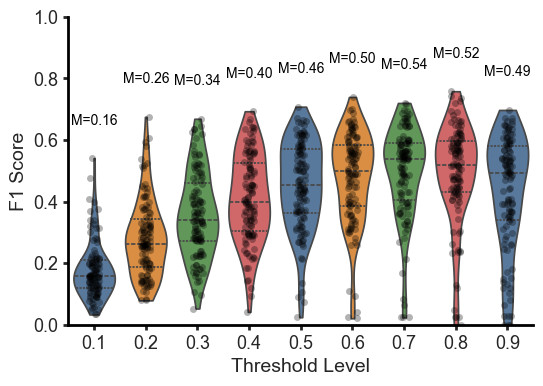

In [22]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())

    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Threshold')[metric].median()
    counts = plot_df.groupby('Threshold')[metric].count()
    mins=plot_df.groupby('Threshold')[metric].min() 
    maxs=plot_df.groupby('Threshold')[metric].max()
    for i, adapt in enumerate(adapt_values):
        if adapt in medians:
            val = medians[adapt]
            min_val = mins[adapt]
            max_val=maxs[adapt]
            ax.text(i, max_val + 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=10, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    # ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    df_plot=df[df["Model"]=="XGBOOST"]
    fig,ax=plot_f1_violin_by_adapt(df_plot, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\NCN\AppData\Local\Temp\ipykernel_5656\1127962853.py:28: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


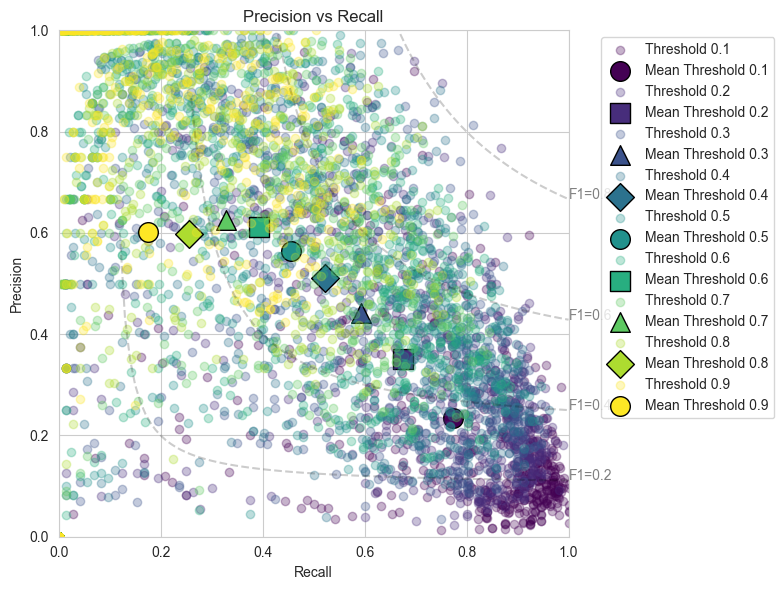

In [12]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    #  # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Threshold"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Threshold {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Threshold {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

In [13]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel",]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Threshold", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values= sorted(df["Threshold"].unique())
    baseline_adapt = 3.0
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Threshold", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Threshold {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

Baseline adapt 3.0 not found in pivot columns.


,Session,Channel,Threshold,Metric,Value
0,2025-09-22_17-42-27,24,0.5,Precision,0.784091
1,2025-09-22_17-42-27,24,0.5,Precision,1.000000
2,2025-09-22_17-42-27,24,0.5,Precision,0.860000
3,2025-09-22_17-42-27,24,0.5,Precision,0.911111
4,2025-09-22_17-42-27,24,0.5,Precision,0.717647


C:\Users\NCN\AppData\Local\Temp\ipykernel_5656\1095338557.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)


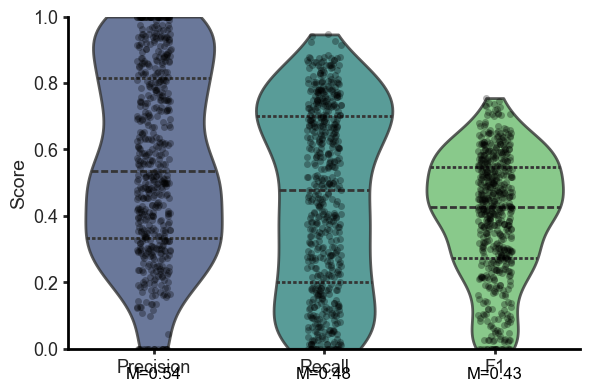

In [14]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Threshold"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Threshold'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Threshold'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Threshold {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Threshold'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    order = list(metrics)
    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=0.5, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    # fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    # fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)

In [15]:
def display_adaptive_threshold_analysis(
    df,
    result_aggregation="median",
    pick_best_row=False,
    merge_back=True,
    verbose=False
):
    """
    Analyzes adaptive threshold performance, standardized to match get_best_per_session_df logic.

    Args:
        df: DataFrame containing metrics.
        result_aggregation: How to summarize the final collection of per-session values ('mean', 'median', 'max').
        pick_best_row: 
            - True: Represents each session by its single best channel (row) after filtering for best threshold.
            - False: Represents each session by the median of all channels (rows) after filtering for best threshold.
        merge_back:
            - True (Required for pick_best_row logic): Merges best threshold back to original data to access channels.
    """

    print(
        f"--- Adaptive Analysis | Pick Best Row: {pick_best_row} | "
        f"Merge Back: {merge_back} | Final Aggregation: {result_aggregation} ---"
    )

    optimized_results = []
    # Metrics to track
    metrics_to_agg = ['F1', 'Precision', 'Recall', 'TP', 'FP', 'FN']
    metrics_to_agg = [m for m in metrics_to_agg if m in df.columns]

    models = df['Model'].unique()

    for model in models:
        if verbose:
            print(f"\nProcessing Model: {model}")
        model_df = df[df['Model'] == model].copy()

        # --- STEP 1: Determine Best Threshold per Session ---
        # Logic: Maximizing MEDIAN F1 across channels for the threshold
        # (This matches get_best_per_session_df Step 1 & 2)
        
        # 1. Aggregate metric by (Session, Threshold)
        grouped = (
            model_df
            .groupby(['Session', 'Threshold'])["F1"]
            .median()
            .reset_index()
        )
        
        # 2. Find Best Config (Threshold) per Session
        best_cfg = (
            grouped
            .sort_values("F1", ascending=False)
            .drop_duplicates(subset=["Session"])
        )
        # best_cfg now contains [Session, Threshold] pairs that are "Optimal"

        # --- STEP 2: Retrieve Full Data for Best Configs ---
        # (Matches matches get_best_per_session_df Step 3)

        if merge_back:
            # Re-join with original data to get ALL rows (channels) for the chosen (Session, Threshold) pairs
            out = model_df.merge(
                best_cfg[['Session', 'Threshold']],
                on=['Session', 'Threshold'],
                how='inner'
            )
        else:
            # Fallback (rarely used given requirements): just use the aggregated values from finding step
            # Note: This loses precision/recall/TP info if not carried over
            out = best_cfg
            
        # --- STEP 3: Reduce to One Row Per Session ---
        # (Matches get_best_per_session_df Step 4)

        if pick_best_row and merge_back:
            # Option A: Pick the SINGLE BEST channel/row for that session
            per_session_df = (
                out
                .sort_values("F1", ascending=False)
                .drop_duplicates(subset=["Session"])
            )
        else:
            # Option B: Aggregate (Median) all channels for that session
            # This collapses the distribution of channels into one median vector per session
            per_session_df = (
                out
                .groupby("Session")[metrics_to_agg]
                .median()
                .reset_index()
            )
        if verbose:
            print(f"Number of sessions: {len(per_session_df)}")
            display(per_session_df)
        # --- STEP 4: Global Aggregation across Sessions ---
        # Summarize the per_session_df into one row for the table
        
        if result_aggregation == 'mean':
            agg_perf = per_session_df[metrics_to_agg].mean()
        elif result_aggregation == 'median':
            agg_perf = per_session_df[metrics_to_agg].median()
        elif result_aggregation == 'max':
            agg_perf = per_session_df[metrics_to_agg].max()
        else:
            agg_perf = per_session_df[metrics_to_agg].agg(result_aggregation)

        agg_perf['Model'] = model
        optimized_results.append(agg_perf)

    summary = pd.DataFrame(optimized_results)
    if not summary.empty:
        cols = ['Model'] + metrics_to_agg
        summary = summary[cols].sort_values(by='F1', ascending=False)
        display(summary.round(3))
    else:
        print("No data found.")

In [16]:
# Load RipplAI Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplAI.csv")

if os.path.exists(results_path):
    ripplAI_df = pd.read_csv(results_path)
    print(f"Loaded {len(ripplAI_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in ripplAI_df.columns:
        ripplAI_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
    
    ripplAI_df['Model'] = ripplAI_df['Model'].str.extract(r'(CNN1D|CNN2D|LSTM|SVM|XGBOOST)', expand=False)

    print("Columns:", ripplAI_df.columns.tolist())
    print("Threshold:", sorted(ripplAI_df["Threshold"].unique()))
    
    display(ripplAI_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 6050 rows from spikes\all_networks_metrics_ripplAI.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-22_17-42-27,24,0.1,CNN1D,96,256,13,0.272727,0.880734,0.416486,10.148958,421,109,10.506607
1,2025-09-22_17-42-27,24,0.1,CNN1D,61,17,48,0.782051,0.559633,0.652406,13.282514,82,109,10.506607
2,2025-09-22_17-42-27,24,0.1,CNN1D,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109,10.506607
3,2025-09-22_17-42-27,24,0.1,CNN1D,73,40,36,0.646018,0.669725,0.657658,9.045662,116,109,10.506607
4,2025-09-22_17-42-27,24,0.1,CNN1D,87,207,22,0.295918,0.798165,0.431762,7.213410,324,109,10.506607


In [17]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions



sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 

sessions_to_reject.update(hfo_sessions)
ripplAI_df=ripplAI_df[~ripplAI_df["Session"].isin(sessions_to_reject)]

In [18]:
display_adaptive_threshold_analysis(
    ripplAI_df,
    result_aggregation="median",
    pick_best_row=False,
    merge_back=True,
    verbose=True
)

--- Adaptive Analysis | Pick Best Row: False | Merge Back: True | Final Aggregation: median ---

Processing Model: CNN1D
Number of sessions: 23


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.652406,0.600000,0.743119,81.0,54.0,28.0
1,2025-09-22_17-55-26,0.725076,0.754286,0.713514,132.0,43.0,53.0
2,2025-09-23_15-50-26,0.536398,0.573770,0.568345,79.0,56.0,60.0
3,2025-09-23_16-17-52,0.158730,0.212500,0.097222,7.0,9.0,65.0
4,2025-09-24_10-24-40,0.311475,0.378947,0.434783,40.0,59.0,52.0
5,2025-09-24_11-34-51,0.473118,0.382609,0.619718,44.0,71.0,27.0
6,2025-09-24_16-29-07,0.389610,0.405405,0.550000,22.0,30.0,18.0
7,2025-09-25_11-21-53,0.460274,0.477912,0.495050,100.0,130.0,102.0
8,2025-09-25_16-41-14,0.581395,0.555000,0.604167,87.0,89.0,57.0
9,Calb_251209_160255,0.579710,0.800000,0.439394,29.0,6.0,37.0



Processing Model: CNN2D
Number of sessions: 23


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.254335,0.619048,0.201835,22.0,8.0,87.0
1,2025-09-22_17-55-26,0.528302,0.651376,0.454054,84.0,38.0,101.0
2,2025-09-23_15-50-26,0.493392,0.636364,0.482014,67.0,32.0,72.0
3,2025-09-23_16-17-52,0.218182,0.236111,0.236111,17.0,55.0,55.0
4,2025-09-24_10-24-40,0.273292,0.318841,0.304348,28.0,47.0,64.0
5,2025-09-24_11-34-51,0.097087,0.154519,0.070423,5.0,27.0,66.0
6,2025-09-24_16-29-07,0.231884,0.275362,0.200000,8.0,27.0,32.0
7,2025-09-25_11-21-53,0.430108,0.525000,0.381188,77.0,78.0,125.0
8,2025-09-25_16-41-14,0.441176,0.620000,0.319444,46.0,34.0,98.0
9,Calb_251209_160255,0.630631,0.781250,0.621212,41.0,7.0,25.0



Processing Model: LSTM
Number of sessions: 23


...


Processing Model: SVM
Number of sessions: 23


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.547170,0.604651,0.495413,54.0,36.0,55.0
1,2025-09-22_17-55-26,0.515723,0.616541,0.443243,82.0,51.0,103.0
2,2025-09-23_15-50-26,0.419476,0.437500,0.395683,55.0,72.0,84.0
3,2025-09-23_16-17-52,0.137500,0.125000,0.166667,12.0,77.0,60.0
4,2025-09-24_10-24-40,0.288210,0.248175,0.336957,31.0,88.0,61.0
5,2025-09-24_11-34-51,0.280488,0.247312,0.323944,23.0,70.0,48.0
6,2025-09-24_16-29-07,0.395062,0.390244,0.400000,16.0,26.0,24.0
7,2025-09-25_11-21-53,0.338983,0.230088,0.663366,134.0,443.0,68.0
8,2025-09-25_16-41-14,0.468665,0.385650,0.569444,82.0,137.0,62.0
9,Calb_251209_160255,0.629921,0.655738,0.606061,40.0,21.0,26.0



Processing Model: XGBOOST
Number of sessions: 23


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.659574,0.784810,0.568807,62.0,17.0,47.0
1,2025-09-22_17-55-26,0.658610,0.744828,0.589189,109.0,37.0,76.0
2,2025-09-23_15-50-26,0.583333,0.659794,0.503597,70.0,33.0,69.0
3,2025-09-23_16-17-52,0.125000,0.081081,0.263889,19.0,198.0,53.0
4,2025-09-24_10-24-40,0.391960,0.351351,0.423913,39.0,72.0,53.0
5,2025-09-24_11-34-51,0.319489,0.221591,0.591549,42.0,137.0,29.0
6,2025-09-24_16-29-07,0.527273,0.510204,0.675000,27.0,24.0,13.0
7,2025-09-25_11-21-53,0.602740,0.618280,0.589109,119.0,71.0,83.0
8,2025-09-25_16-41-14,0.564626,0.666667,0.500000,72.0,36.0,72.0
9,Calb_251209_160255,0.690141,0.741379,0.712121,47.0,15.0,19.0


,Model,F1,Precision,Recall,TP,FP,FN
4,XGBOOST,0.583,0.660,0.589,67.0,36.0,46.0
2,LSTM,0.579,0.567,0.643,69.0,41.0,44.0
0,CNN1D,0.524,0.555,0.550,61.0,54.0,44.0
3,SVM,0.484,0.438,0.504,57.0,56.0,55.0
1,CNN2D,0.450,0.525,0.441,46.0,38.0,58.0


In [19]:
display_adaptive_threshold_analysis(
    ripplAI_df,
    result_aggregation="median",
    pick_best_row=True,
    merge_back=True,
    verbose=True    
)

--- Adaptive Analysis | Pick Best Row: True | Merge Back: True | Final Aggregation: median ---

Processing Model: CNN1D
Number of sessions: 23


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
7,2025-09-22_17-55-26,26,0.1,CNN1D,132,43,53,0.754286,0.713514,0.733333,9.346212,179,185,10.399793
75,Calb_251210_165332,15,0.3,CNN1D,72,43,19,0.626087,0.791209,0.699029,18.279630,122,91,11.109689
2,2025-09-22_17-42-27,24,0.1,CNN1D,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109,10.506607
32,2025-09-25_16-41-14,21,0.1,CNN1D,111,89,33,0.555000,0.770833,0.645349,10.751351,208,144,10.424501
67,Calb_251211_105518,12,0.2,CNN1D,89,58,42,0.605442,0.679389,0.640288,15.459176,146,131,10.845724
95,Calb_251210_162849,15,0.6,CNN1D,85,68,28,0.555556,0.752212,0.639098,13.970196,161,113,11.705316
80,Calb_251209_160255,11,0.4,CNN1D,42,25,24,0.626866,0.636364,0.631579,20.959524,69,66,5.828693
63,Calb_251211_104316,5,0.2,CNN1D,59,27,45,0.686047,0.567308,0.621053,16.498870,86,104,11.098311
38,Calb_251210_164150,15,0.1,CNN1D,88,80,30,0.523810,0.745763,0.615385,10.223106,171,118,10.902613
12,2025-09-23_15-50-26,28,0.1,CNN1D,79,56,60,0.585185,0.568345,0.576642,10.316034,135,139,10.387618



Processing Model: CNN2D
Number of sessions: 23


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
60,Calb_251209_160255,11,0.2,CNN2D,46,3,20,0.938776,0.696970,0.800000,9.362319,49,66,5.828693
80,Calb_251210_165332,15,0.2,CNN2D,52,4,39,0.928571,0.571429,0.707483,14.835897,56,91,11.109689
74,Calb_251210_162849,15,0.2,CNN2D,74,30,39,0.711538,0.654867,0.682028,12.357658,105,113,11.705316
50,Calbai32FPGA_251003_144832,11,0.2,CNN2D,130,76,63,0.631068,0.673575,0.651629,7.596667,208,193,11.366827
45,2025-09-25_16-41-14,21,0.2,CNN2D,86,34,58,0.716667,0.597222,0.651515,14.207752,120,144,10.424501
10,2025-09-23_15-50-26,28,0.1,CNN2D,74,15,65,0.831461,0.532374,0.649123,12.252252,88,139,10.387618
5,2025-09-22_17-55-26,26,0.1,CNN2D,89,4,96,0.956989,0.481081,0.640288,12.178277,94,185,10.399793
75,Calb_251210_164150,15,0.2,CNN2D,63,16,55,0.797468,0.533898,0.639594,11.416402,81,118,10.902613
65,Calb_251210_122327,13,0.2,CNN2D,52,22,39,0.702703,0.571429,0.630303,7.062179,74,91,10.954382
0,2025-09-22_17-42-27,24,0.1,CNN2D,51,5,58,0.910714,0.467890,0.618182,15.083660,59,109,10.506607



Processing Model: LSTM
Number of sessions: 23


...


Processing Model: SVM
Number of sessions: 23


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
78,Calb_251210_165332,15,0.7,SVM,59,14,32,0.808219,0.648352,0.719512,27.669492,141,91,11.109689
66,Calb_251209_160255,11,0.7,SVM,41,20,25,0.672131,0.621212,0.645669,25.812195,142,66,5.828693
71,Calb_251210_164150,15,0.7,SVM,68,48,50,0.586207,0.576271,0.581197,28.295098,200,118,10.902613
102,Calb_251210_162849,15,0.9,SVM,58,30,55,0.659091,0.513274,0.577114,28.720690,112,113,11.705316
20,2025-09-22_17-42-27,24,0.4,SVM,53,23,56,0.697368,0.486239,0.572973,27.685535,148,109,10.506607
95,Calb_251210_122327,13,0.8,SVM,54,44,37,0.551020,0.593407,0.571429,24.430864,225,91,10.954382
44,Calb_251211_105518,12,0.5,SVM,88,93,43,0.486188,0.671756,0.564103,32.956818,379,131,10.845724
58,Calb_251211_104316,5,0.6,SVM,57,43,47,0.570000,0.548077,0.558824,33.933333,187,104,11.098311
14,2025-09-22_17-55-26,26,0.3,SVM,89,61,96,0.593333,0.481081,0.531343,26.982397,306,185,10.399793
52,Calbai32FPGA_251003_150055,5,0.6,SVM,107,110,79,0.493088,0.575269,0.531017,26.738941,342,186,11.173404



Processing Model: XGBOOST
Number of sessions: 23


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
64,Calb_251209_160255,11,0.8,XGBOOST,47,11,19,0.810345,0.712121,0.758065,17.380851,60,66,5.828693
76,Calb_251210_165332,15,0.8,XGBOOST,64,17,27,0.790123,0.703297,0.744186,20.010417,85,91,11.109689
31,2025-09-22_17-42-27,24,0.7,XGBOOST,71,27,38,0.724490,0.651376,0.685990,19.153991,103,109,10.506607
72,Calb_251210_164150,15,0.8,XGBOOST,73,28,45,0.722772,0.618644,0.666667,20.453881,105,118,10.902613
13,2025-09-22_17-55-26,26,0.5,XGBOOST,129,74,56,0.635468,0.697297,0.664948,14.540827,216,185,10.399793
97,Calb_251210_162849,15,0.9,XGBOOST,67,23,46,0.744444,0.592920,0.660099,19.246766,96,113,11.705316
92,Calb_251210_121141,15,0.9,XGBOOST,35,8,34,0.813953,0.507246,0.625000,16.900952,45,69,10.848569
82,Calb_251211_105518,12,0.8,XGBOOST,86,59,45,0.593103,0.656489,0.623188,24.294961,161,131,10.845724
19,2025-09-25_11-21-53,21,0.5,XGBOOST,119,64,83,0.650273,0.589109,0.618182,25.266667,195,202,10.375892
65,Calb_251210_122327,13,0.8,XGBOOST,51,26,40,0.662338,0.560440,0.607143,19.200000,78,91,10.954382


,Model,F1,Precision,Recall,TP,FP,FN
2,LSTM,0.648,0.706,0.646,73.0,21.0,39.0
4,XGBOOST,0.602,0.641,0.567,67.0,36.0,45.0
1,CNN2D,0.594,0.681,0.534,57.0,22.0,52.0
0,CNN1D,0.570,0.555,0.593,72.0,54.0,37.0
3,SVM,0.500,0.490,0.486,58.0,54.0,55.0
